แสดงหน้าต่างกราฟแล้ว... ลองเลื่อน Slider เพื่อจูนค่าได้เลยครับ


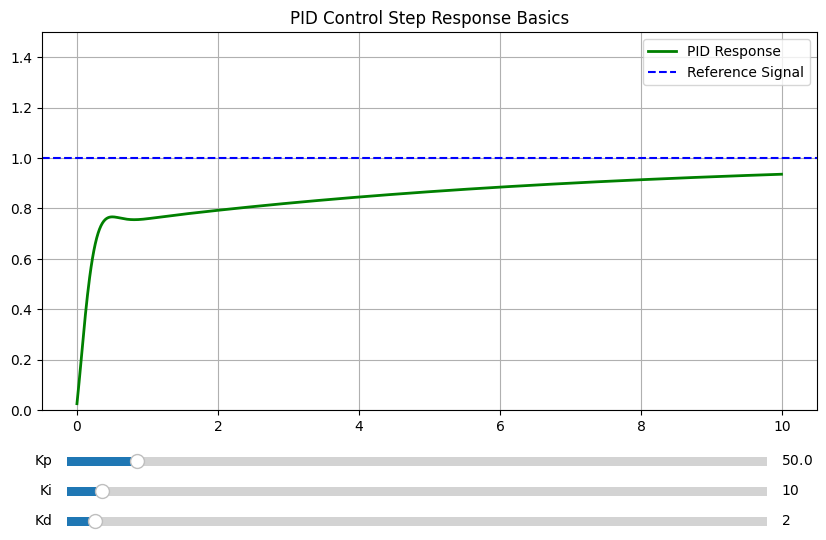

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# --- 1. จำลองระบบ (Plant Model) ---
# เราจะจำลองระบบกริปเปอร์หรือมอเตอร์เป็น Second-order system ง่ายๆ
def system_update(y, dy, u, dt=0.01):
    # สมการ: ddy + 10*dy + 20*y = u (ตัวอย่างระบบที่มีความหน่วงและมวล)
    ddy = u - 10*dy - 20*y
    new_dy = dy + ddy * dt
    new_y = y + new_dy * dt
    return new_y, new_dy

# --- 2. ฟังก์ชันหลักสำหรับรัน Simulation ---
def simulate_pid(kp, ki, kd, t_end=10, dt=0.01, setpoint=1.0):
    t = np.arange(0, t_end, dt)
    y_history = []
    
    y, dy = 0, 0
    error_integral = 0
    last_error = 0
    
    for _ in t:
        error = setpoint - y
        error_integral += error * dt
        derivative = (error - last_error) / dt
        
        # PID Formula
        u = (kp * error) + (ki * error_integral) + (kd * derivative)
        
        # Update System
        y, dy = system_update(y, dy, u, dt)
        y_history.append(y)
        last_error = error
        
    return t, np.array(y_history)

# --- 3. การแสดงผลและส่วนควบคุม (UI) ---
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.25)

# ค่าเริ่มต้น
init_kp, init_ki, init_kd = 50.0, 10.0, 2.0
t, y = simulate_pid(init_kp, init_ki, init_kd)

line, = ax.plot(t, y, lw=2, color='green', label='PID Response')
ax.axhline(1.0, color='blue', ls='--', label='Reference Signal') # Setpoint
ax.set_ylim(0, 1.5)
ax.grid(True)
ax.legend()
ax.set_title("PID Control Step Response Basics")

# สร้าง Sliders สำหรับปรับค่า
ax_kp = plt.axes([0.15, 0.15, 0.7, 0.03])
ax_ki = plt.axes([0.15, 0.10, 0.7, 0.03])
ax_kd = plt.axes([0.15, 0.05, 0.7, 0.03])

s_kp = Slider(ax_kp, 'Kp', 0.1, 500.0, valinit=init_kp)
s_ki = Slider(ax_ki, 'Ki', 0.0, 200.0, valinit=init_ki)
s_kd = Slider(ax_kd, 'Kd', 0.0, 50.0, valinit=init_kd)

def update(val):
    new_t, new_y = simulate_pid(s_kp.val, s_ki.val, s_kd.val)
    line.set_ydata(new_y)
    fig.canvas.draw_idle()

s_kp.on_changed(update)
s_ki.on_changed(update)
s_kd.on_changed(update)

print("แสดงหน้าต่างกราฟแล้ว... ลองเลื่อน Slider เพื่อจูนค่าได้เลยครับ")
plt.show()